Running models on phishing_site_urls dataset...
Dataset Shape:  (1085309, 2)
                                                 URL Label
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3  mail.printakid.com/www.online.americanexpress....   bad
4  thewhiskeydregs.com/wp-content/themes/widescre...   bad
Removed 6 rows with unexpected labels.

LOGISTIC REGRESSION MODEL
Accuracy: 93.78023348311226 %

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.82      0.88     89817
           1       0.94      0.98      0.96    235774

    accuracy                           0.94    325591
   macro avg       0.94      0.90      0.92    325591
weighted avg       0.94      0.94      0.94    325591


Classification Report Table:


,precision,recall,f1-score,support
0,0.943321,0.824042,0.879657,89817.000000
1,0.936050,0.981139,0.958064,235774.000000
accuracy,0.937802,0.937802,0.937802,0.937802
macro avg,0.939686,0.902590,0.918860,325591.000000
weighted avg,0.938056,0.937802,0.936435,325591.000000


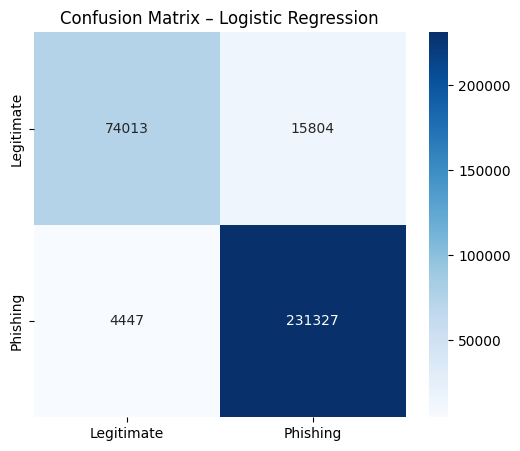

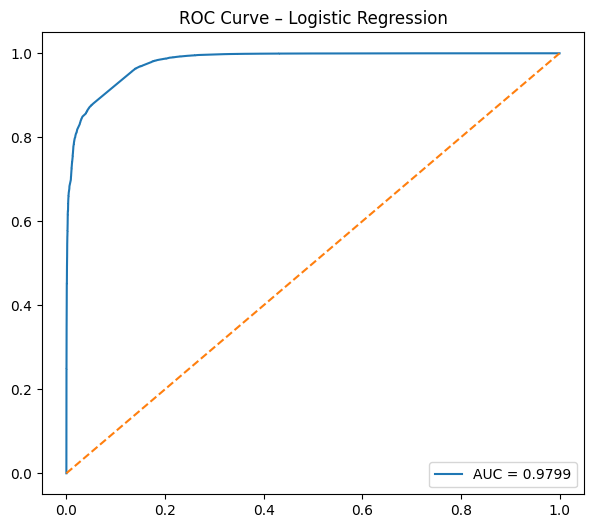

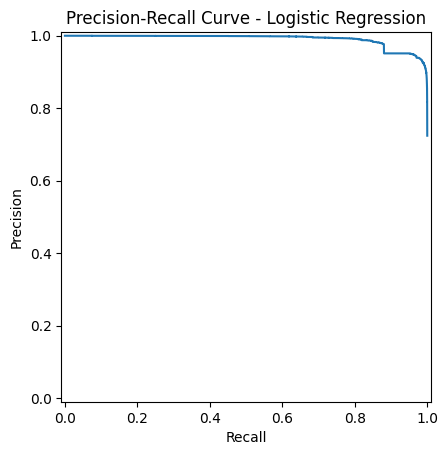


LINEAR REGRESSION MODEL
MAE: 0.14919958995321486
MSE: 0.055561072821931005
RMSE: 0.2357139639943527
R2 Score: 0.7218616015868837
Classification Accuracy: 93.50074172811902 %

Linear Regression Metrics Table:


,Metric,Value
0,MAE,0.149200
1,MSE,0.055561
2,RMSE,0.235714
3,R2 Score,0.721862
4,Classification Accuracy,93.500742


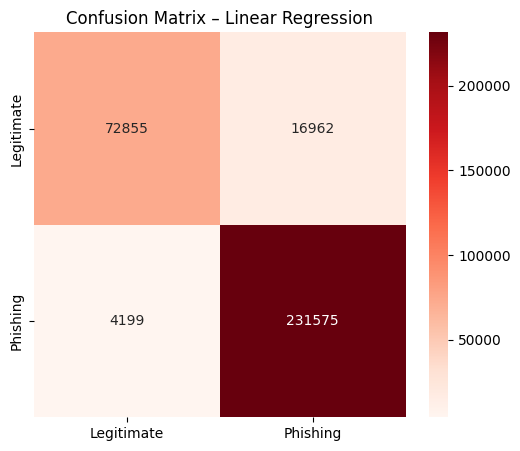

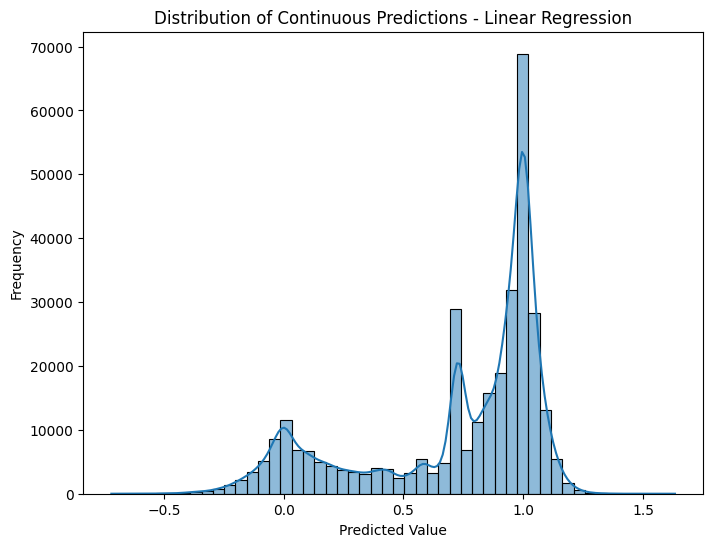

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, mean_absolute_error, mean_squared_error, r2_score,
    precision_recall_curve, PrecisionRecallDisplay
)

print("Running models on phishing_site_urls dataset...")

# ==============================
# 1. Load Dataset
# ==============================

file_path = "/content/phishing_site_urls.csv"
df = pd.read_csv(file_path, sep=',', on_bad_lines='skip')

print("Dataset Shape: ", df.shape)
print(df.head())

# ==============================
# 2. Data Preprocessing
# ==============================

# Rename columns if necessary
df.columns = ['URL', 'Label']

# Filter out any labels other than 'bad' or 'good' to ensure binary classification
initial_row_count = df.shape[0]
df = df[df['Label'].isin(['bad', 'good'])]
if df.shape[0] < initial_row_count:
    print(f"Removed {initial_row_count - df.shape[0]} rows with unexpected labels.")

# Encode Labels (phishing = 1, legitimate = 0)
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

X_text = df['URL']
y = df['Label']

# Convert text → numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X_text)

# ==============================
# 3. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# =================================================
#           LOGISTIC REGRESSION MODEL
# =================================================

print("\nLOGISTIC REGRESSION MODEL")

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:,1]

# Accuracy
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", accuracy_logistic*100, "%")

print("\nClassification Report:\n")
class_report = classification_report(y_test, y_pred_logistic, output_dict=True)
print(classification_report(y_test, y_pred_logistic))

# Display classification report as a table
class_report_df = pd.DataFrame(class_report).transpose()
print("\nClassification Report Table:")
display(class_report_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_logistic)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_logistic)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()


# =================================================
#           LINEAR REGRESSION MODEL
# =================================================

print("\nLINEAR REGRESSION MODEL")

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Continuous prediction
y_pred_cont = linear_model.predict(X_test)

# Convert to binary (threshold 0.5)
y_pred_linear = [1 if val > 0.5 else 0 for val in y_pred_cont]

# Metrics
mae = mean_absolute_error(y_test, y_pred_cont)
mse = mean_squared_error(y_test, y_pred_cont)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_cont)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Classification Accuracy:", accuracy_linear*100, "%")

# Display regression metrics as a table
metrics_data = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score', 'Classification Accuracy'],
    'Value': [mae, mse, rmse, r2, accuracy_linear * 100]
}
metrics_df = pd.DataFrame(metrics_data)
print("\nLinear Regression Metrics Table:")
display(metrics_df)

# Confusion Matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6,5))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
plt.title("Confusion Matrix – Linear Regression")
plt.show()

# Histogram of Continuous Predictions
plt.figure(figsize=(8, 6))
sns.histplot(y_pred_cont, bins=50, kde=True)
plt.title('Distribution of Continuous Predictions - Linear Regression')
plt.xlabel('Predicted Value')
plt.ylabel('Frequency')
plt.show()